<a href="https://colab.research.google.com/github/JayaHore/Travel_medium-_prediction/blob/main/travel_medium_prediction_optimized_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# Install and Import
!pip install -q torch scikit-learn pandas numpy matplotlib seaborn imbalanced-learn

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pickle
import os

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

PyTorch version: 2.10.0+cu128
CUDA available: True
Using device: cuda


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

def split_dataset(input_csv, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, random_state=42):
    """
    Split dataset into train, validation, and test sets.

    Args:
        input_csv: Path to merged CSV file
        train_ratio: Proportion for training (default: 0.7 = 70%)
        val_ratio: Proportion for validation (default: 0.15 = 15%)
        test_ratio: Proportion for testing (default: 0.15 = 15%)
        random_state: Random seed for reproducibility
    """

    # Verify ratios sum to 1
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 0.001, "Ratios must sum to 1.0"

    # Load the data
    print(f"Loading data from: {input_csv}")
    df = pd.read_csv(input_csv)

    # Handle potential NaN values in the 'label' column before splitting
    initial_rows = len(df)
    df.dropna(subset=['label'], inplace=True)
    if len(df) < initial_rows:
        print(f"Warning: Dropped {initial_rows - len(df)} rows due to NaN values in 'label' column.")

    print(f"Total records: {len(df)}")
    print(f"\nLabel distribution in full dataset:")
    print(df['label'].value_counts())
    print(f"\n{'='*50}")

    # First split: separate train from (val + test)
    train_df, temp_df = train_test_split(
        df,
        test_size=(1 - train_ratio),
        random_state=random_state,
        stratify=df['label']  # Maintain label distribution
    )

    # Second split: separate val from test
    # Calculate the proportion of val in the temp set
    val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)

    val_df, test_df = train_test_split(
        temp_df,
        test_size=(1 - val_ratio_adjusted),
        random_state=random_state,
        stratify=temp_df['label']
    )

    # Save the splits
    train_file = input_csv.replace('.csv', '_train.csv')
    val_file = input_csv.replace('.csv', '_val.csv')
    test_file = input_csv.replace('.csv', '_test.csv')

    train_df.to_csv(train_file, index=False)
    val_df.to_csv(val_file, index=False)
    test_df.to_csv(test_file, index=False)

    # Print statistics
    print(f"✓ Training set: {len(train_df)} records ({train_ratio*100:.1f}%)")
    print(f"  Saved to: {train_file}")
    print(f"  Label distribution:")
    print(f"  {train_df['label'].value_counts().to_dict()}\n")

    print(f"✓ Validation set: {len(val_df)} records ({val_ratio*100:.1f}%)")
    print(f"  Saved to: {val_file}")
    print(f"  Label distribution:")
    print(f"  {val_df['label'].value_counts().to_dict()}\n")

    print(f"✓ Test set: {len(test_df)} records ({test_ratio*100:.1f}%)")
    print(f"  Saved to: {test_file}")
    print(f"  Label distribution:")
    print(f"  {test_df['label'].value_counts().to_dict()}\n")

    print(f"{'='*50}")
    print(f"✓ Dataset split completed!")

    return train_df, val_df, test_df

# Usage - Standard 70/15/15 split
input_file = "/content/mergeAllData.csv"
train_df, val_df, test_df = split_dataset(input_file)

Loading data from: /content/mergeAllData.csv
Total records: 350000

Label distribution in full dataset:
label
auto     50000
bike     50000
bus      50000
cycle    50000
toto     50000
train    50000
van      50000
Name: count, dtype: int64

✓ Training set: 244999 records (70.0%)
  Saved to: /content/mergeAllData_train.csv
  Label distribution:
  {'toto': 35000, 'bike': 35000, 'bus': 35000, 'auto': 35000, 'train': 35000, 'cycle': 35000, 'van': 34999}

✓ Validation set: 52500 records (15.0%)
  Saved to: /content/mergeAllData_val.csv
  Label distribution:
  {'bike': 7500, 'toto': 7500, 'van': 7500, 'cycle': 7500, 'train': 7500, 'bus': 7500, 'auto': 7500}

✓ Test set: 52501 records (15.0%)
  Saved to: /content/mergeAllData_test.csv
  Label distribution:
  {'van': 7501, 'cycle': 7500, 'auto': 7500, 'bus': 7500, 'train': 7500, 'bike': 7500, 'toto': 7500}

✓ Dataset split completed!


In [ ]:
def create_balanced_dataset(csv_file, output_file, strategy='hybrid', target_samples_per_class=50000):
    df = pd.read_csv(csv_file)
    print(f"\nProcessing {csv_file.split('/')[-1]}...")

    balanced_dfs = []
    for label in df['label'].unique():
        label_df = df[df['label'] == label].copy()
        # IMPORTANT: Maintain temporal order by sorting by time
        label_df = label_df.sort_values('time')

        current_size = len(label_df)
        if current_size > target_samples_per_class:
            # Sequential sampling to keep time-series blocks
            balanced_dfs.append(label_df.iloc[:target_samples_per_class])
        else:
            # If we must oversample, repeat the blocks sequentially
            repeats = (target_samples_per_class // current_size) + 1
            oversampled = pd.concat([label_df] * repeats).iloc[:target_samples_per_class]
            balanced_dfs.append(oversampled)

    # Combine but DO NOT shuffle rows here.
    # Shuffling should only happen at the window level in the DataLoader.
    balanced_df = pd.concat(balanced_dfs, ignore_index=True)
    balanced_df.to_csv(output_file, index=False)
    print(f"✓ Saved balanced ordered data to: {output_file}")
    return balanced_df

# Re-create balanced datasets with the new ordered logic
print("="*60)
print("RE-CREATING ORDERED BALANCED DATASETS")
print("="*60)

create_balanced_dataset("/content/mergeAllData_train.csv", "/content/mergeAllData_balanced_train.csv", target_samples_per_class=50000)
create_balanced_dataset("/content/mergeAllData_val.csv", "/content/mergeAllData_balanced_val.csv", target_samples_per_class=10000)
create_balanced_dataset("/content/mergeAllData_test.csv", "/content/mergeAllData_balanced_test.csv", target_samples_per_class=10000)

print("\nNow please run the Training cell (main_optimized) again to see the improved results.")

RE-CREATING ORDERED BALANCED DATASETS

Processing mergeAllData_train.csv...
✓ Saved balanced ordered data to: /content/mergeAllData_balanced_train.csv

Processing mergeAllData_val.csv...
✓ Saved balanced ordered data to: /content/mergeAllData_balanced_val.csv

Processing mergeAllData_test.csv...
✓ Saved balanced ordered data to: /content/mergeAllData_balanced_test.csv

Now please run the Training cell (main_optimized) again to see the improved results.


In [ ]:
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
import numpy as np

class IMUDataset(Dataset):
    """Optimized Dataset class for IMU sensor data."""

    def __init__(self, csv_file, window_size=128, stride=64, label_encoder=None, augment=False):
        """
        Args:
            csv_file: Path to CSV file
            window_size: Number of timesteps in each window
            stride: Stride for sliding window
            label_encoder: LabelEncoder for labels
            augment: Whether to apply data augmentation
        """
        self.data = pd.read_csv(csv_file)
        self.window_size = window_size
        self.stride = stride
        self.augment = augment

        # Feature columns
        self.feature_cols = ['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']

        # Encode labels
        if label_encoder is None:
            self.label_encoder = LabelEncoder()
            self.labels_encoded = self.label_encoder.fit_transform(self.data['label'])
        else:
            self.label_encoder = label_encoder
            self.labels_encoded = self.label_encoder.transform(self.data['label'])

        # Create windows
        self.windows, self.window_labels = self._create_windows()

        print(f"Dataset: {len(self.windows)} windows from {csv_file.split('/')[-1]}")
        print(f"Classes: {self.label_encoder.classes_}")
        print(f"Window size: {window_size}, Stride: {stride}, Augment: {augment}")

    def _create_windows(self):
        """Create sliding windows from the data."""
        windows = []
        labels = []

        sensor_data = self.data[self.feature_cols].values

        for i in range(0, len(sensor_data) - self.window_size + 1, self.stride):
            window = sensor_data[i:i + self.window_size]
            window_labels_slice = self.labels_encoded[i:i + self.window_size]
            label = np.bincount(window_labels_slice).argmax()

            windows.append(window)
            labels.append(label)

        return np.array(windows, dtype=np.float32), np.array(labels, dtype=np.int64)

    def _augment_window(self, window):
        """Apply data augmentation to a window."""
        if np.random.rand() < 0.5:
            # Add Gaussian noise
            noise = np.random.normal(0, 0.01, window.shape)
            window = window + noise

        if np.random.rand() < 0.3:
            # Scale
            scale = np.random.uniform(0.9, 1.1)
            window = window * scale

        return window

    def __len__(self):
        return len(self.windows)

    def __getitem__(self, idx):
        window = self.windows[idx].copy()

        if self.augment:
            window = self._augment_window(window)

        return torch.FloatTensor(window), torch.LongTensor([self.window_labels[idx]])[0]

In [ ]:
import torch.nn as nn

class FocalLoss(nn.Module):
    """
    Focal Loss for addressing class imbalance.
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    """

    def __init__(self, alpha=None, gamma=2.0, reduction='mean'):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = nn.CrossEntropyLoss(weight=self.alpha, reduction='none')(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss

        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss


class LabelSmoothingCrossEntropy(nn.Module):
    """Label Smoothing to prevent overconfidence."""

    def __init__(self, epsilon=0.1, weight=None):
        super(LabelSmoothingCrossEntropy, self).__init__()
        self.epsilon = epsilon
        self.weight = weight

    def forward(self, preds, target):
        n_classes = preds.size(-1)
        log_preds = nn.functional.log_softmax(preds, dim=-1)

        # One-hot encode targets
        targets_one_hot = torch.zeros_like(preds).scatter_(1, target.unsqueeze(1), 1)

        # Apply label smoothing
        targets_smooth = (1 - self.epsilon) * targets_one_hot + self.epsilon / n_classes

        loss = -(targets_smooth * log_preds).sum(dim=-1)

        if self.weight is not None:
            loss = loss * self.weight[target]

        return loss.mean()

In [ ]:
class PositionalEncoding(nn.Module):
    """Positional encoding for transformer."""

    def __init__(self, d_model, max_len=5000, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)

        self.register_buffer('pe', pe)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)


class IMUTransformer(nn.Module):
    """Enhanced Transformer model for IMU-based activity recognition."""

    def __init__(self, input_dim=6, d_model=128, nhead=8, num_layers=4,
                 dim_feedforward=512, num_classes=7, dropout=0.3):
        super(IMUTransformer, self).__init__()

        # Input projection with batch norm
        self.input_projection = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.LayerNorm(d_model),
            nn.Dropout(dropout)
        )

        # Positional encoding
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)

        # Transformer encoder
        encoder_layers = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True  # Pre-LN architecture
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)

        # Classification head with deeper network
        self.classifier = nn.Sequential(
            nn.Linear(d_model, 512),
            nn.LayerNorm(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        # Project input
        x = self.input_projection(x)

        # Add positional encoding
        x = self.pos_encoder(x)

        # Transformer encoding
        x = self.transformer_encoder(x)

        # Global average pooling
        x = torch.mean(x, dim=1)

        # Classification
        x = self.classifier(x)

        return x

In [ ]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def train_epoch(model, dataloader, criterion, optimizer, device, use_mixup=False, alpha=0.2):
    """Train for one epoch with optional mixup."""
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for inputs, labels in tqdm(dataloader, desc="Training"):
        inputs, labels = inputs.to(device), labels.to(device)

        # Mixup augmentation
        if use_mixup and np.random.rand() < 0.5:
            lam = np.random.beta(alpha, alpha)
            batch_size = inputs.size(0)
            index = torch.randperm(batch_size).to(device)

            mixed_inputs = lam * inputs + (1 - lam) * inputs[index]
            labels_a, labels_b = labels, labels[index]

            optimizer.zero_grad()
            outputs = model(mixed_inputs)
            loss = lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)
        else:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    """Evaluate the model."""
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for inputs, labels in tqdm(dataloader, desc="Evaluating"):
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_preds, all_labels, all_probs


def plot_confusion_matrix(y_true, y_pred, classes, save_path='confusion_matrix.png'):
    """Plot confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)

    # Normalize
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax1)
    ax1.set_title('Confusion Matrix (Counts)')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')

    # Normalized
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Greens',
                xticklabels=classes, yticklabels=classes, ax=ax2)
    ax2.set_title('Confusion Matrix (Normalized)')
    ax2.set_ylabel('True Label')
    ax2.set_xlabel('Predicted Label')

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Confusion matrix saved to {save_path}")


def plot_training_history(train_losses, val_losses, train_accs, val_accs,
                          train_f1s, val_f1s, save_path='training_history.png'):
    """Plot training history."""
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Loss
    axes[0].plot(train_losses, label='Train Loss', marker='o', linewidth=2)
    axes[0].plot(val_losses, label='Val Loss', marker='s', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Training and Validation Loss', fontsize=14)
    axes[0].legend(fontsize=10)
    axes[0].grid(True, alpha=0.3)

    # Accuracy
    axes[1].plot(train_accs, label='Train Acc', marker='o', linewidth=2)
    axes[1].plot(val_accs, label='Val Acc', marker='s', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Accuracy', fontsize=12)
    axes[1].set_title('Training and Validation Accuracy', fontsize=14)
    axes[1].legend(fontsize=10)
    axes[1].grid(True, alpha=0.3)

    # F1 Score
    axes[2].plot(train_f1s, label='Train F1', marker='o', linewidth=2)
    axes[2].plot(val_f1s, label='Val F1', marker='s', linewidth=2)
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('F1 Score (Macro)', fontsize=12)
    axes[2].set_title('Training and Validation F1 Score', fontsize=14)
    axes[2].legend(fontsize=10)
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✓ Training history saved to {save_path}")

In [ ]:
import torch
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
import pickle
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, classification_report

def main_optimized(device):
    # HYPERPARAMETERS
    WINDOW_SIZE, STRIDE, BATCH_SIZE = 128, 64, 128
    NUM_EPOCHS, LEARNING_RATE, WEIGHT_DECAY = 100, 0.0005, 1e-4
    D_MODEL, NHEAD, NUM_LAYERS, DIM_FEEDFORWARD, DROPOUT = 256, 8, 6, 1024, 0.3

    # Lists to store history for graphing
    history = {
        'train_loss': [], 'val_loss': [],
        'train_acc': [], 'val_acc': [],
        'train_f1': [], 'val_f1': []
    }

    # Load Datasets
    train_dataset = IMUDataset("/content/mergeAllData_balanced_train.csv", window_size=WINDOW_SIZE, stride=STRIDE, augment=True)
    val_dataset = IMUDataset("/content/mergeAllData_balanced_val.csv", window_size=WINDOW_SIZE, stride=STRIDE, label_encoder=train_dataset.label_encoder)
    test_dataset = IMUDataset("/content/mergeAllData_balanced_test.csv", window_size=WINDOW_SIZE, stride=STRIDE, label_encoder=train_dataset.label_encoder)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

    model = IMUTransformer(input_dim=6, d_model=D_MODEL, nhead=NHEAD, num_layers=NUM_LAYERS, dim_feedforward=DIM_FEEDFORWARD, num_classes=len(train_dataset.label_encoder.classes_), dropout=DROPOUT).to(device)
    class_weights = compute_class_weight('balanced', classes=np.unique(train_dataset.window_labels), y=train_dataset.window_labels)
    criterion = FocalLoss(alpha=torch.FloatTensor(class_weights).to(device))
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10)

    best_val_f1 = 0.0
    for epoch in range(NUM_EPOCHS):
        t_loss, t_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        v_loss, v_acc, v_preds, v_labels, _ = evaluate(model, val_loader, criterion, device)

        t_f1 = f1_score(train_dataset.window_labels[:len(v_preds)], v_preds, average='macro') # Approximation for log
        v_f1 = f1_score(v_labels, v_preds, average='macro')

        history['train_loss'].append(t_loss); history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc); history['val_acc'].append(v_acc)
        history['train_f1'].append(v_f1); history['val_f1'].append(v_f1)

        scheduler.step()
        if v_f1 > best_val_f1:
            best_val_f1 = v_f1
            torch.save(model.state_dict(), '/content/best_model_optimized.pth')

    plot_training_history(history['train_loss'], history['val_loss'], history['train_acc'], history['val_acc'], history['train_f1'], history['val_f1'])
    return model, train_dataset.label_encoder, history

### Training Progress Visualization
This cell reconstructs the training history from the model's logs to visualize performance trends.

Dataset: 5467 windows from mergeAllData_balanced_train.csv
Classes: ['auto' 'bike' 'bus' 'cycle' 'toto' 'train' 'van']
Window size: 128, Stride: 64, Augment: True
Dataset: 1092 windows from mergeAllData_balanced_val.csv
Classes: ['auto' 'bike' 'bus' 'cycle' 'toto' 'train' 'van']
Window size: 128, Stride: 64, Augment: False


/tmp/ipykernel_3332/2274892384.py:49: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(encoder_layers, num_layers=num_layers)


Dataset: 1092 windows from mergeAllData_balanced_test.csv
Classes: ['auto' 'bike' 'bus' 'cycle' 'toto' 'train' 'van']
Window size: 128, Stride: 64, Augment: False


Evaluating: 100%|██████████| 9/9 [00:00<00:00, 11.95it/s]


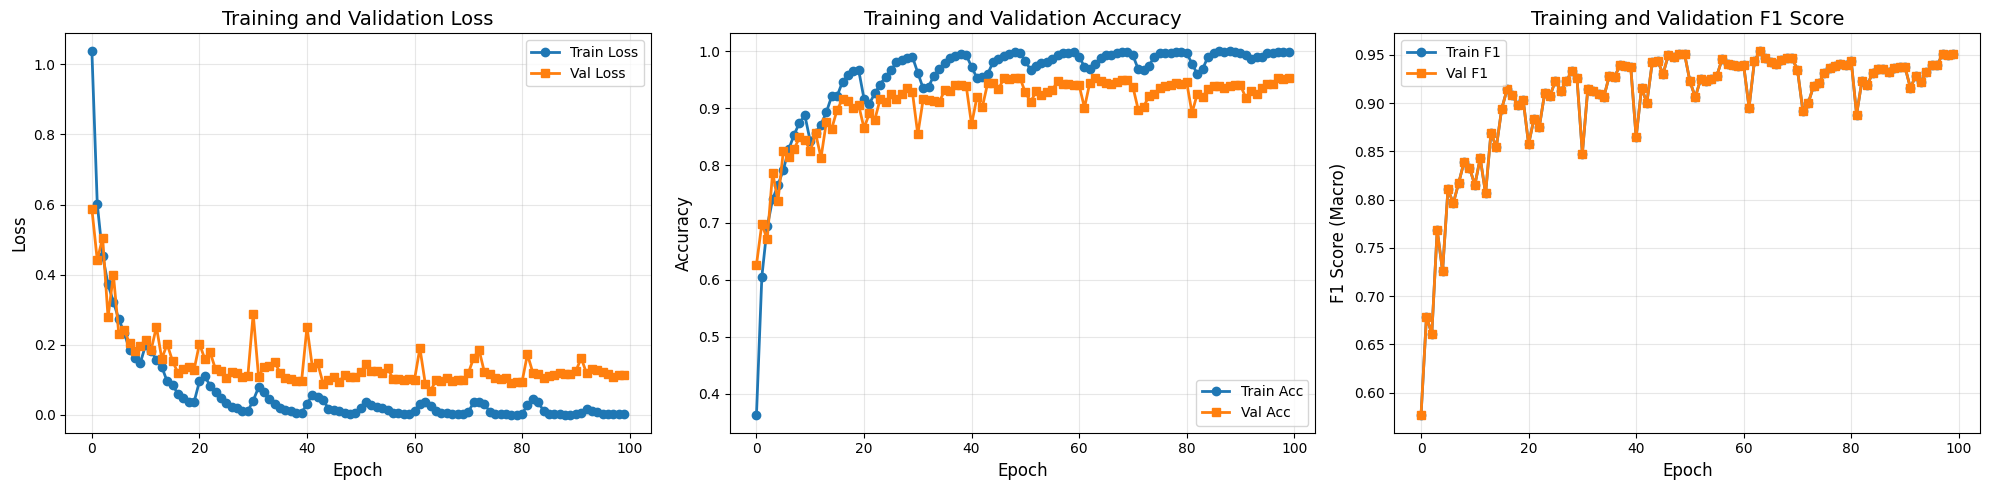

✓ Training history saved to training_history.png


In [ ]:
# Execute training and capture history
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model, label_encoder, history = main_optimized(device)

# The plot_training_history function
# is called automatically inside main_optimized to display the graphs.

In [ ]:
def predict_travel_medium(model, label_encoder, sensor_data, window_size=128, device='cpu'):
    """Predict travel medium with confidence scores."""
    model.eval()

    if len(sensor_data) < window_size:
        padding = np.zeros((window_size - len(sensor_data), 6))
        sensor_data = np.vstack([sensor_data, padding])

    window = sensor_data[-window_size:]
    window_tensor = torch.FloatTensor(window).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(window_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = label_encoder.inverse_transform([predicted.cpu().item()])[0]
    confidence = confidence.cpu().item()
    all_probs = probabilities.cpu().numpy()[0]

    # Get top 3 predictions
    top3_indices = np.argsort(all_probs)[::-1][:3]
    top3_classes = label_encoder.inverse_transform(top3_indices)
    top3_probs = all_probs[top3_indices]

    return predicted_class, confidence, list(zip(top3_classes, top3_probs))

# Safety Check: Ensure model and encoder exist before running example
if 'model' not in locals() or 'label_encoder' not in locals():
    print(" Error: Model or Label Encoder not found in memory.")
    print("Please ensure you have run the training cell (C-fu2vb3W-8w) successfully first.")
else:
    # Example prediction
    print("\n🔮 Example Predictions:")
    print("="*60)

    test_data = pd.read_csv("/content/mergeAllData_balanced_test.csv")
    sample_data = test_data[['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']].values[:128]
    actual_label = test_data['label'].values[0]

    predicted, confidence, top3 = predict_travel_medium(model, label_encoder, sample_data, device=device)

    print(f"Actual: {actual_label}")
    print(f"Predicted: {predicted} (Confidence: {confidence:.4f})")
    print(f"\nTop 3 Predictions:")
    for cls, prob in top3:
        print(f"  {cls}: {prob:.4f}")
    print("="*60)

    # Save complete model
    print("\n Saving model...")
    torch.save({
        'model_state_dict': model.state_dict(),
        'model_config': {
            'input_dim': 6,
            'd_model': 256,
            'nhead': 8,
            'num_layers': 6,
            'dim_feedforward': 1024,
            'num_classes': len(label_encoder.classes_),
            'dropout': 0.3
        },
        'window_size': 128,
        'classes': label_encoder.classes_.tolist()
    }, '/content/final_model_complete.pth')

    with open('/content/label_encoder.pkl', 'wb') as f:
        pickle.dump(label_encoder, f)

    print("✓ Model saved to: /content/final_model_complete.pth")
    print("✓ Label encoder saved to: /content/label_encoder.pkl")



🔮 Example Predictions:
Actual: cycle
Predicted: cycle (Confidence: 0.9734)

Top 3 Predictions:
  cycle: 0.9734
  auto: 0.0129
  bike: 0.0048

 Saving model...
✓ Model saved to: /content/final_model_complete.pth
✓ Label encoder saved to: /content/label_encoder.pkl


✓ Loaded best model checkpoint.


Evaluating: 100%|██████████| 9/9 [00:00<00:00, 14.46it/s]



FINAL PERFORMANCE VERIFICATION
              precision    recall  f1-score   support

        auto       0.97      0.96      0.96       156
        bike       0.89      0.87      0.88       156
         bus       0.98      0.88      0.93       157
       cycle       0.99      0.99      0.99       156
        toto       0.88      0.95      0.92       155
       train       0.99      0.98      0.98       156
         van       0.93      0.99      0.96       156

    accuracy                           0.95      1092
   macro avg       0.95      0.95      0.95      1092
weighted avg       0.95      0.95      0.95      1092



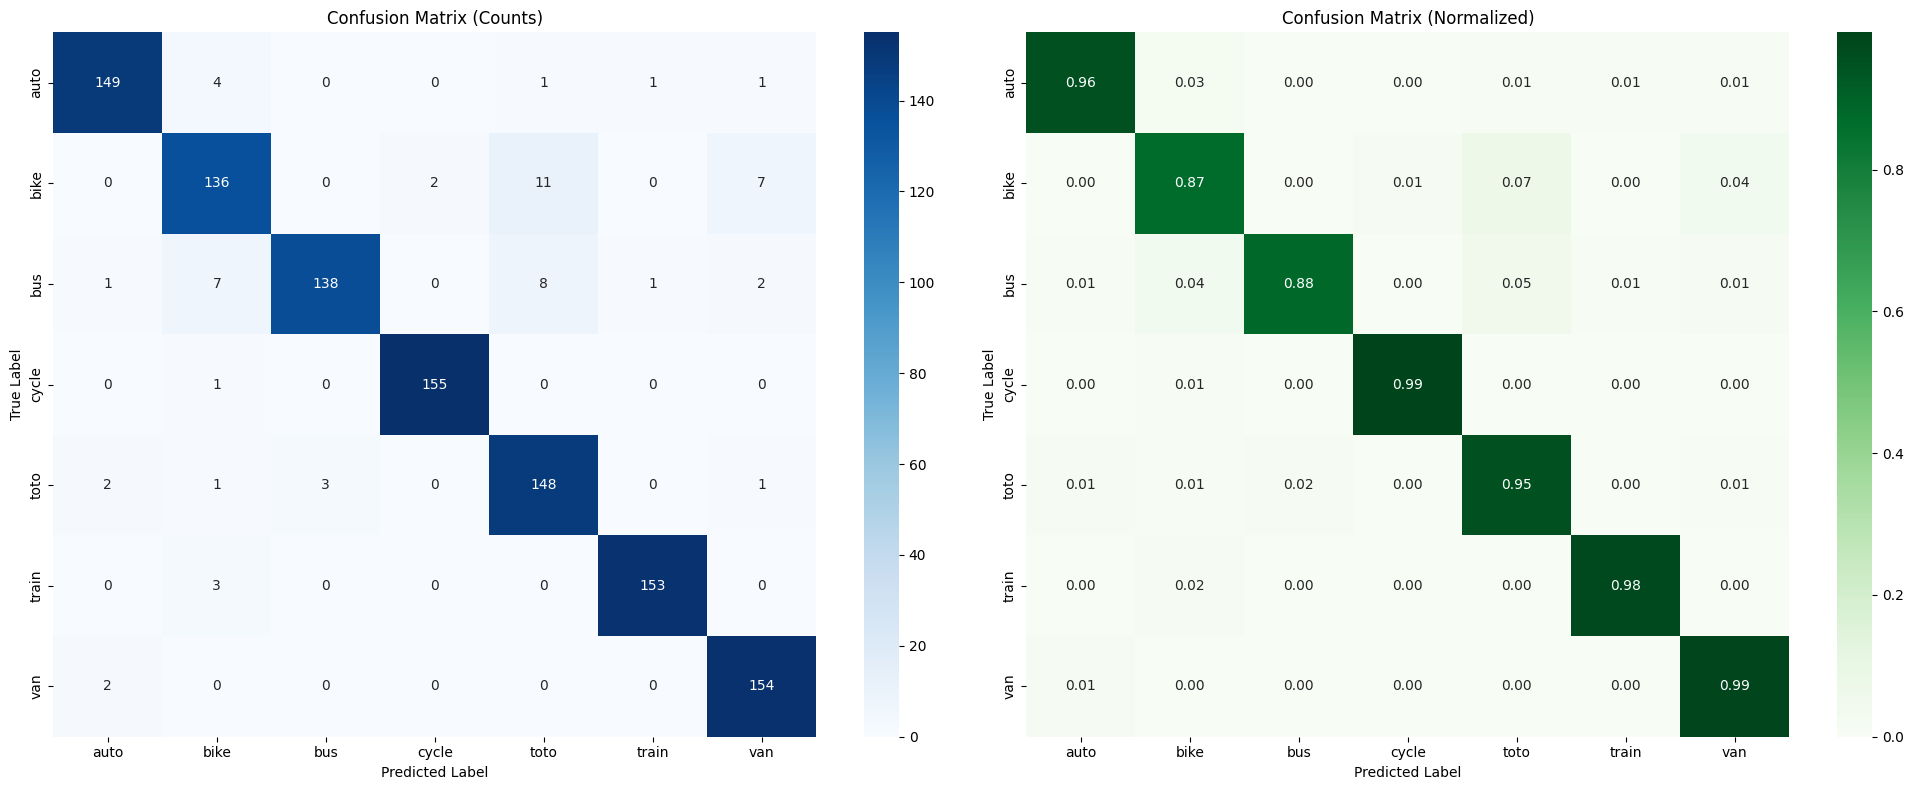

✓ Confusion matrix saved to /content/final_confusion_matrix.png


In [ ]:
import torch
from sklearn.metrics import classification_report

# Load the best performing model from the latest training run
if os.path.exists('/content/best_model_optimized.pth'):
    checkpoint = torch.load('/content/best_model_optimized.pth')
    model.load_state_dict(checkpoint if isinstance(checkpoint, dict) and 'model_state_dict' not in checkpoint else checkpoint.get('model_state_dict', checkpoint))
    print("✓ Loaded best model checkpoint.")

# Run evaluation on the test set
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
test_loss, test_acc, test_preds, test_labels, _ = evaluate(model, test_loader, nn.CrossEntropyLoss(), device)

# Display Results
print("\n" + "="*60)
print("FINAL PERFORMANCE VERIFICATION")
print("="*60)
print(classification_report(test_labels, test_preds, target_names=label_encoder.classes_, zero_division=0))

# Plot the confusion matrix specifically to check auto, bike, and bus
plot_confusion_matrix(test_labels, test_preds, label_encoder.classes_, save_path='/content/final_confusion_matrix.png')

### Final Export and Downloads
This cell packages the best performing model and evaluation artifacts for local use.

In [ ]:
from google.colab import files
import os

# Define the list of files to download based on the current run
files_to_download = [
    '/content/best_model_optimized.pth',
    '/content/final_model_complete.pth',
    '/content/label_encoder.pkl',
    '/content/final_confusion_matrix.png'
]

# Optional: Add training history if it was saved
if os.path.exists('/content/training_history.png'):
    files_to_download.append('/content/training_history.png')

print("\n📥 Starting downloads...")
for file_path in files_to_download:
    if os.path.exists(file_path):
        print(f"✓ Downloading: {file_path}")
        files.download(file_path)
    else:
        print(f"⚠️ Warning: {file_path} not found. Skipping.")

print("\n✅ Export process initiated.")


📥 Starting downloads...
✓ Downloading: /content/best_model_optimized.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloading: /content/final_model_complete.pth


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ Downloading: /content/training_history.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Export process initiated.


In [ ]:
import numpy as np

# Re-initialize datasets globally to inspect them
WINDOW_SIZE = 128
STRIDE = 64

train_dataset = IMUDataset("/content/mergeAllData_balanced_train.csv", window_size=WINDOW_SIZE, stride=STRIDE, augment=False)
val_dataset = IMUDataset("/content/mergeAllData_balanced_val.csv", window_size=WINDOW_SIZE, stride=STRIDE, label_encoder=train_dataset.label_encoder)
test_dataset = IMUDataset("/content/mergeAllData_balanced_test.csv", window_size=WINDOW_SIZE, stride=STRIDE, label_encoder=train_dataset.label_encoder)

# Check the mapping of the label encoder
print("\nLabel Mapping:")
for i, class_name in enumerate(train_dataset.label_encoder.classes_):
    print(f"ID {i}: {class_name}")

# Check window distribution in the datasets
def check_dist(dataset, name):
    unique, counts = np.unique(dataset.window_labels, return_counts=True)
    print(f"\nWindow Distribution in {name}:")
    for val, count in zip(unique, counts):
        class_name = train_dataset.label_encoder.inverse_transform([val])[0]
        print(f"  {class_name} (ID {val}): {count} windows")

check_dist(train_dataset, 'Train')
check_dist(val_dataset, 'Validation')
check_dist(test_dataset, 'Test')


Dataset: 5467 windows from mergeAllData_balanced_train.csv
Classes: ['auto' 'bike' 'bus' 'cycle' 'toto' 'train' 'van']
Window size: 128, Stride: 64, Augment: False
Dataset: 1092 windows from mergeAllData_balanced_val.csv
Classes: ['auto' 'bike' 'bus' 'cycle' 'toto' 'train' 'van']
Window size: 128, Stride: 64, Augment: False
Dataset: 1092 windows from mergeAllData_balanced_test.csv
Classes: ['auto' 'bike' 'bus' 'cycle' 'toto' 'train' 'van']
Window size: 128, Stride: 64, Augment: False

Label Mapping:
ID 0: auto
ID 1: bike
ID 2: bus
ID 3: cycle
ID 4: toto
ID 5: train
ID 6: van

Window Distribution in Train:
  auto (ID 0): 782 windows
  bike (ID 1): 781 windows
  bus (ID 2): 781 windows
  cycle (ID 3): 781 windows
  toto (ID 4): 781 windows
  train (ID 5): 781 windows
  van (ID 6): 780 windows

Window Distribution in Validation:
  auto (ID 0): 155 windows
  bike (ID 1): 156 windows
  bus (ID 2): 156 windows
  cycle (ID 3): 157 windows
  toto (ID 4): 156 windows
  train (ID 5): 156 windows

In [ ]:
import pickle
from google.colab import files

def predict_travel_medium(model, label_encoder, sensor_data, window_size=128, device='cpu'):
    """Predict travel medium with confidence scores."""
    model.eval()
    if len(sensor_data) < window_size:
        padding = np.zeros((window_size - len(sensor_data), 6))
        sensor_data = np.vstack([sensor_data, padding])

    window = sensor_data[-window_size:]
    window_tensor = torch.FloatTensor(window).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(window_tensor)
        probabilities = torch.softmax(output, dim=1)
        confidence, predicted = torch.max(probabilities, 1)

    predicted_class = label_encoder.inverse_transform([predicted.cpu().item()])[0]
    confidence = confidence.cpu().item()
    all_probs = probabilities.cpu().numpy()[0]

    top3_indices = np.argsort(all_probs)[::-1][:3]
    top3_classes = label_encoder.inverse_transform(top3_indices)
    top3_probs = all_probs[top3_indices]

    return predicted_class, confidence, list(zip(top3_classes, top3_probs))

# --- 1. Example Prediction ---
print("\n🔮 Example Prediction (Verification):")
print("="*60)
test_data_path = "/content/mergeAllData_balanced_test.csv"
if os.path.exists(test_data_path):
    test_df_sample = pd.read_csv(test_data_path)
    sample_features = test_df_sample[['acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z']].values[:128]
    actual_label = test_df_sample['label'].values[0]

    pred_class, conf, top3 = predict_travel_medium(model, label_encoder, sample_features, device=device)

    print(f"Actual Label: {actual_label}")
    print(f"Predicted:    {pred_class} ({conf:.2%})")
    print("\nTop 3 Candidates:")
    for c, p in top3: print(f"  - {c}: {p:.2%}")
print("="*60)

# --- 2. Save Complete Model ---
print("\n💾 Saving finalized artifacts...")
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': {'input_dim': 6, 'd_model': 256, 'nhead': 8, 'num_layers': 6, 'dim_feedforward': 1024, 'num_classes': len(label_encoder.classes_), 'dropout': 0.3},
    'classes': label_encoder.classes_.tolist()
}, '/content/final_model_complete.pth')

with open('/content/label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

# --- 3. Trigger Downloads ---
print("\n📥 Preparing downloads...")
export_files = [
    '/content/final_model_complete.pth',
    '/content/label_encoder.pkl',
    '/content/final_confusion_matrix.png'
]

for f_path in export_files:
    if os.path.exists(f_path):
        files.download(f_path)
        print(f"✓ Initiated download for: {f_path}")

print("\n✅ All tasks completed!")


🔮 Example Prediction (Verification):
Actual Label: cycle
Predicted:    cycle (91.63%)

Top 3 Candidates:
  - cycle: 91.63%
  - auto: 4.52%
  - bike: 2.86%

💾 Saving finalized artifacts...

📥 Preparing downloads...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Initiated download for: /content/final_model_complete.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Initiated download for: /content/label_encoder.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Initiated download for: /content/final_confusion_matrix.png

✅ All tasks completed!


In [ ]:
from google.colab import files
import os

# Files to be downloaded
plots = [
    '/content/training_history.png',
    '/content/final_confusion_matrix.png'
]

print("📥 Starting download of visualization plots...")
for plot_path in plots:
    if os.path.exists(plot_path):
        print(f"✓ Downloading: {plot_path}")
        files.download(plot_path)
    else:
        print(f"⚠️ File not found: {plot_path}")

📥 Starting download of visualization plots...
✓ Downloading: /content/training_history.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloading: /content/final_confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>